# Week 7


# Lecture 13: Regularization, Ridge and LASSO Regression, and Cross-Validation

The problem of **overfitting** is an issue where a machine learning model fits too strongly to the training data, which reduces its ability to generalize to make good predictions on the test set. High performance on the test set is typically our most important goal, because this measures how the model performs on data it has not seen before, indicating the model should perform well on real-world data, assuming the test data are representative of the data we hope to predict.

Below, we implement ridge regression, which imposes an $L^2$ penalty on the model parameters to minimize the loss function

$$L(\theta) = \|X\theta - y\|^2 + \lambda_2\|\theta\|^2$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

In [2]:
class RidgeRegression:
    
    def __init__(self, alpha = 0.001, lambda2 = 0):
        # save variables to object memory
        self.alpha = alpha
        self.lambda2 = lambda2
        
    # fit the model to the data
    def fit(self, X, y, epochs = 1000, update = 100):
        # find the dimension of the data
        d = X.shape[1]
        
        # initialize the model parameters
        self.theta0 = np.random.uniform()
        self.theta = np.random.uniform(size = d)
        
        # compute the means of X and y
        yMean = np.mean(y)
        xMean = np.mean(X, axis = 0)
        
        # standardize the data
        X = scale(X)
        y = scale(y)
        
        # compute a scaling parameter
        eta = np.linalg.norm(X)
        
        # train the model
        for i in range(epochs):
            # compute the predicted y values
            predictions = self.theta0 + X @ self.theta
            
            # compute the error
            error = predictions - y
            
            # compute the sum of squared errors
            sse = np.sum(error ** 2)
            
            # compute the loss
            loss = sse + self.lambda2 * np.linalg.norm(self.theta) ** 2 #+ self.lambda1 * np.sum(np.abs(self.theta))

            # print an update
            if (i + 1) % update == 0:
                print('Epoch', i + 1, '\tLoss', loss)
                                                
            # weight update for the bias
            self.theta -= self.alpha * (X.T @ error + 2 * self.lambda2 * self.theta)
            self.theta0 = yMean - xMean @ self.theta

    # predict the output from input (testing) data
    def predict(self, X):
        # return the predicted outputs
        return self.theta0 + X @ self.theta

Let's test it on a small, simple dataset to check that it works.

Epoch 10 	Loss 30.99233886905759
Epoch 20 	Loss 15.963356371329532
Epoch 30 	Loss 8.326949445389527
Epoch 40 	Loss 4.8280371062671446
Epoch 50 	Loss 3.575931351589637
Epoch 60 	Loss 3.4863419976443106
Epoch 70 	Loss 3.9486373509603365
Epoch 80 	Loss 4.628068093393975
Epoch 90 	Loss 5.348714105108488
Epoch 100 	Loss 6.024602447060918
The predicted y values are [2.12829514 2.36414757 2.6        2.83585243 3.07170486]
The real y values are [1 2 3 3 4]
The theta values are [0.71318057 0.23585243]
The r^2 score is 0.5280135239321685
The mean squared error is 0.4908659351105449
The mean absolute error is 0.5969770850578974


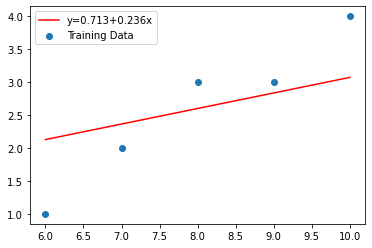

In [3]:
X = np.array([[6], [7], [8], [9], [10]])
y = np.array([1, 2, 3, 3, 4])

model = RidgeRegression(lambda2 = 10)
model.fit(X, y, epochs = 100, update = 10)
predictions = model.predict(X)

# print the predictions
print('The predicted y values are', predictions)

# print the real y values
print('The real y values are', y)

# print the beta values
parameters = np.concatenate((np.atleast_1d(model.theta0), model.theta))
print('The theta values are', parameters)

# plot the training points
plt.scatter(X, y, label = 'Training Data')

# plot the fitted model with the training data
xModel = np.linspace(6,10,100)
yModel = parameters[0] + parameters[1]*xModel
lineFormula = 'y={:.3f}+{:.3f}x'.format(parameters[0], parameters[1])
plt.plot(xModel, yModel, 'r', label = lineFormula)

# add a legend
plt.legend()

# return quality metrics
print('The r^2 score is', r2_score(y, predictions))
print('The mean squared error is', mean_squared_error(y, predictions))
print('The mean absolute error is', mean_absolute_error(y, predictions))

# Lecture 14: Decision Tree Classifiers

We will use the following (slightly modified) tutorial from https://scikit-learn.org/stable/auto_examples/tree/plot_iris_dtc.html.

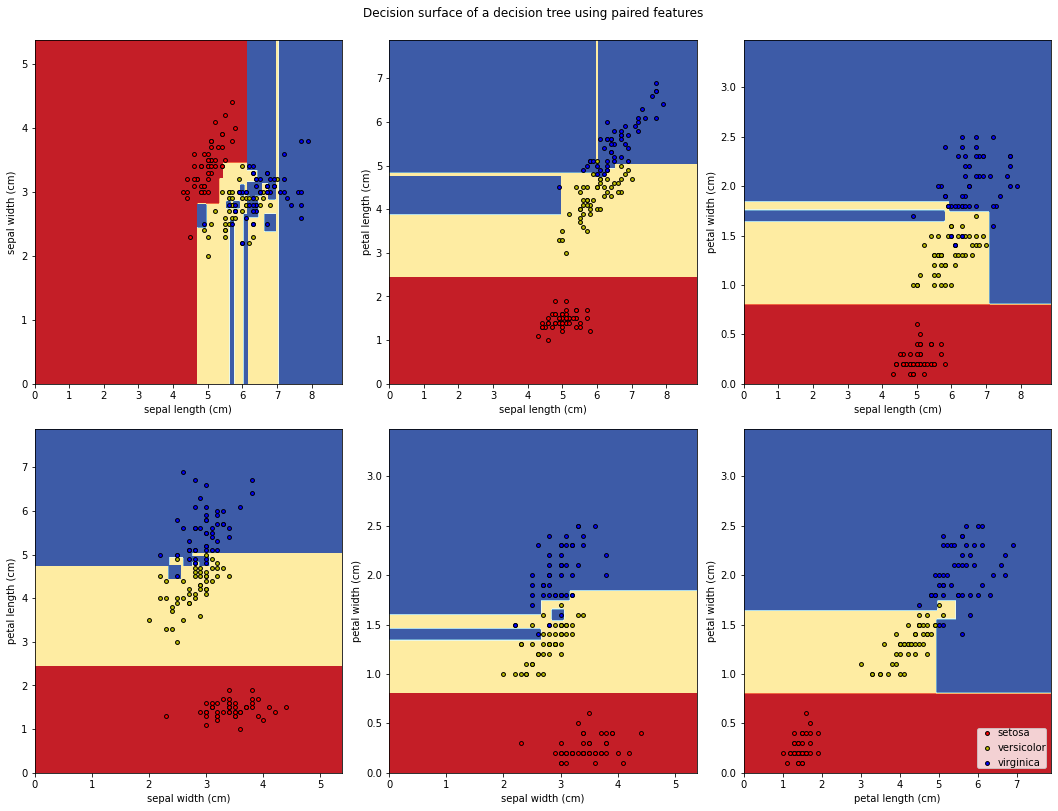

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# hyperparameters
n_classes = 3
plot_colors = 'ryb'
plot_step = 0.02

# Load the iris dataset
iris = load_iris()

plt.figure(figsize=(16,12))

# run the model for each pair of features
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    # take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # fit the classifier
    clf = DecisionTreeClassifier().fit(X, y)

    # plot the decision boundary
    plt.subplot(2, 3, pairidx + 1)

    # predict the testing data on a tight mesh of points in space and color-code them
    x_min, x_max = 0, X[:, 0].max() + 1
    y_min, y_max = 0, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))

    plt.tight_layout(h_pad=1, w_pad=1, pad=5)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])

    # plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i], cmap=plt.cm.RdYlBu, edgecolor='black', s=15)

plt.suptitle('Decision surface of a decision tree using paired features')
plt.legend(loc='lower right', borderpad=0, handletextpad=0)

[Text(446.4, 597.96, 'petal width (cm) <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]\nclass = setosa'),
 Text(377.7230769230769, 489.24, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]\nclass = setosa'),
 Text(515.0769230769231, 489.24, 'petal width (cm) <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]\nclass = versicolor'),
 Text(274.7076923076923, 380.52000000000004, 'petal length (cm) <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]\nclass = versicolor'),
 Text(137.35384615384615, 271.8, 'petal width (cm) <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]\nclass = versicolor'),
 Text(68.67692307692307, 163.07999999999998, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]\nclass = versicolor'),
 Text(206.03076923076924, 163.07999999999998, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(412.0615384615385, 271.8, 'petal width (cm) <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]\nclass = virginica'),
 Text(343.38461538461536, 163.0

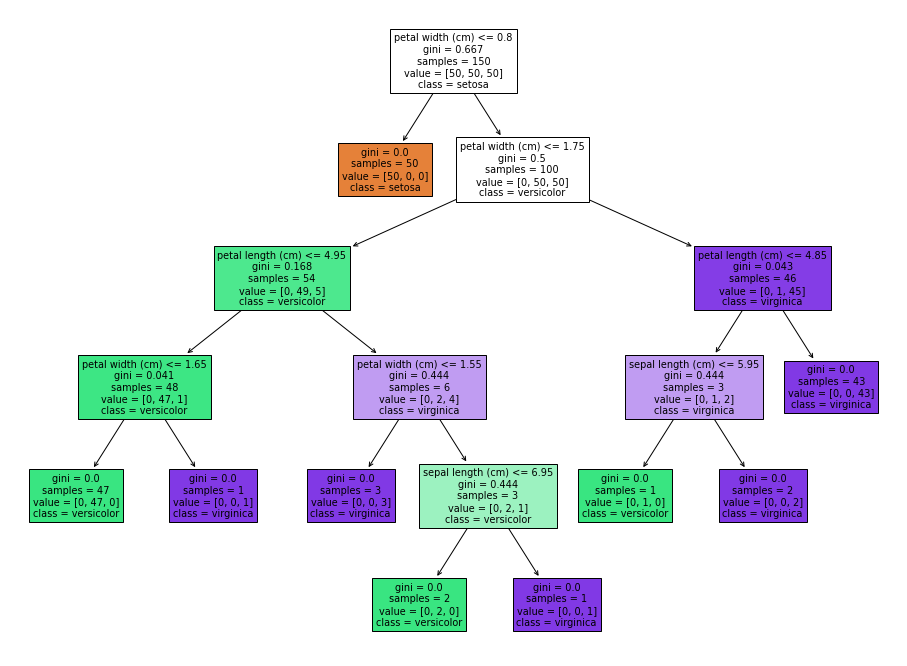

In [2]:
# plot a tree fit to the whole dataset
clf = DecisionTreeClassifier().fit(iris.data, iris.target)
plt.figure(figsize=(16,12))
plot_tree(clf, filled=True, feature_names = iris.feature_names, class_names = iris.target_names)